# Module 5 — Day 2: Training Neural Networks from Scratch
## PHY 657, Spring 2026

---

### Recap from Day 1

Last time we:
- Showed that a single neuron = logistic regression
- Introduced the Ising model and saw that logistic regression struggles because the relevant feature ($|M|$) is non-linear
- Built the forward pass: matrix multiply, activation, repeat

Today we answer the key question: **How does the network learn?**

### Plan
1. The loss function
2. Gradient descent (review from Module 3)
3. Backpropagation = the chain rule
4. From-scratch implementation in numpy
5. Apply to XOR and the Ising model
6. Hyperparameter exploration

---
## Part 0: Setup and reload data

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 14, 'figure.figsize': (8, 6)})


def relu(z):
    return np.maximum(0, z)
    
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def tanh_func(z):
    return np.tanh(z)

def forward(X, W1, b1, W2, b2):
    z1 = X @ W1.T + b1
    h = sigmoid(z1)
    z2 = h @ W2 + b2
    y_hat = sigmoid(z2)
    return y_hat, h

In [3]:
# Load Ising data from Day 1
data = np.load('ising_data.npz')
X_ising, y_ising, T_ising = data['X'], data['y'], data['T']

X_tr_is, X_te_is, y_tr_is, y_te_is = train_test_split(
    X_ising, y_ising, test_size=0.3, random_state=0, stratify=y_ising
)

# Logistic regression baseline from Day 1
clf_lr_is = LogisticRegression(max_iter=1000)
clf_lr_is.fit(X_tr_is, y_tr_is)
acc_lr = clf_lr_is.score(X_te_is, y_te_is)
print(f'Logistic regression accuracy: {acc_lr:.2%}')
print(f'Data loaded: {X_ising.shape[0]} samples, {X_ising.shape[1]} features')

Logistic regression accuracy: 67.17%
Data loaded: 2000 samples, 100 features


---
## Part 1: The Loss Function

We need a measure of how wrong the network is. For binary classification, we use the **binary cross-entropy** loss — the same loss as logistic regression:

$$\mathcal{L} = -\frac{1}{N}\sum_{n=1}^{N} \left[ y_n \log \hat{y}_n + (1 - y_n) \log(1 - \hat{y}_n) \right]$$

This is just the negative log-likelihood under a Bernoulli model — maximizing the likelihood is the same as minimizing the cross-entropy. Same principle as Module 1 (MLE) and Module 3 (regression likelihood).

In [4]:
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

---
## Part 2: Gradient Descent (review)

We already met gradient descent in Module 3 (minimizing the regression loss). The same idea applies here:

$$\theta \leftarrow \theta - \eta \frac{\partial \mathcal{L}}{\partial \theta}$$

where $\theta$ represents all the parameters ($\mathbf{W}^{(1)}, \mathbf{b}^{(1)}, \mathbf{w}^{(2)}, b^{(2)}$) and $\eta$ is the learning rate.

The challenge: how do we compute $\partial \mathcal{L} / \partial \theta$ for parameters deep inside the network?

---
## Part 3: Backpropagation = the Chain Rule

Backpropagation is just the **chain rule of calculus**, applied systematically from the output layer backward.

<img src="forward_backward_pass.svg" width="700">

For our 2-layer network with sigmoid activations, the gradients work out to:

**Output layer:**
$$\delta^{(2)} = \hat{y} - y$$
$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}^{(2)}} = \frac{1}{N} \mathbf{h}^T \boldsymbol{\delta}^{(2)}$$
$$\frac{\partial \mathcal{L}}{\partial b^{(2)}} = \frac{1}{N} \sum \delta^{(2)}$$

**Hidden layer:**
$$\boldsymbol{\delta}^{(1)} = \left(\boldsymbol{\delta}^{(2)} \cdot \mathbf{w}^{(2)T}\right) \odot \mathbf{h} \odot (1 - \mathbf{h})$$
$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(1)}} = \frac{1}{N} \boldsymbol{\delta}^{(1)T} \mathbf{X}$$
$$\frac{\partial \mathcal{L}}{\partial \mathbf{b}^{(1)}} = \frac{1}{N} \sum \boldsymbol{\delta}^{(1)}$$

where $\odot$ is element-wise multiplication and $\mathbf{h} \odot (1 - \mathbf{h})$ is the derivative of the sigmoid.



### Where does $\delta^{(2)} = \hat{y} - y$ come from?

This result comes from combining the cross-entropy derivative with the sigmoid derivative:

$$\frac{\partial \mathcal{L}}{\partial z^{(2)}} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z^{(2)}} = \left(-\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}\right) \cdot \hat{y}(1-\hat{y}) = \hat{y} - y$$

The sigmoid and cross-entropy are natural partners — this cancellation is why they are often used together.

In [5]:
def backward(X, y, y_hat, h, W2):
    """Backpropagation for a 2-layer network."""
    N = len(y)
    delta2 = (y_hat - y)
    dW2 = (h.T @ delta2) / N
    db2 = np.mean(delta2)
    delta1 = np.outer(delta2, W2) * h * (1 - h)
    dW1 = (delta1.T @ X) / N
    db1 = np.mean(delta1, axis=0)
    return dW1, db1, dW2, db2

---
## Part 4: Putting It All Together — Training from Scratch

Now we combine the forward pass, loss computation, and backward pass into a training loop.

In [10]:
def train_network(X, y, H=4, lr=0.5, n_epochs=2000, verbose=True, ndiv=500):
    N, D = X.shape
    rng = np.random.default_rng(0)
    W1 = rng.standard_normal((H, D)) * 0.5
    b1 = np.zeros(H)
    W2 = rng.standard_normal(H) * 0.5
    b2 = 0.0
    losses = []
    for epoch in range(n_epochs):
        y_hat, h = forward(X, W1, b1, W2, b2)
        loss = binary_cross_entropy(y, y_hat)
        losses.append(loss)
        dW1, db1_g, dW2, db2_g = backward(X, y, y_hat, h, W2)
        W1 -= lr * dW1
        b1 -= lr * db1_g
        W2 -= lr * dW2
        b2 -= lr * db2_g
        if verbose and epoch % ndiv == 0:
            acc = np.mean((y_hat > 0.5).astype(int) == y)
            print(f'  epoch {epoch:5d}  loss = {loss:.4f}  acc = {acc:.2%}')
    return W1, b1, W2, b2, losses

### The XOR problem: the simplest non-linear test

Before tackling the Ising model, let us verify our network on the classic XOR problem — the simplest task that a single neuron (logistic regression) provably cannot solve.

In [11]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

print('Training on XOR problem...')
W1_xor, b1_xor, W2_xor, b2_xor, losses_xor = train_network(
    X_xor, y_xor, H=4, lr=2.0, n_epochs=5000
)

y_pred_xor, _ = forward(X_xor, W1_xor, b1_xor, W2_xor, b2_xor)
print(f'\nFinal predictions: {y_pred_xor.round(3)}')
print(f'True labels:       {y_xor}')

Training on XOR problem...
  epoch     0  loss = 0.7468  acc = 50.00%
  epoch   500  loss = 0.0175  acc = 100.00%
  epoch  1000  loss = 0.0056  acc = 100.00%
  epoch  1500  loss = 0.0032  acc = 100.00%
  epoch  2000  loss = 0.0022  acc = 100.00%
  epoch  2500  loss = 0.0017  acc = 100.00%
  epoch  3000  loss = 0.0014  acc = 100.00%
  epoch  3500  loss = 0.0011  acc = 100.00%
  epoch  4000  loss = 0.0010  acc = 100.00%
  epoch  4500  loss = 0.0009  acc = 100.00%

Final predictions: [0.001 0.999 0.999 0.001]
True labels:       [0. 1. 1. 0.]


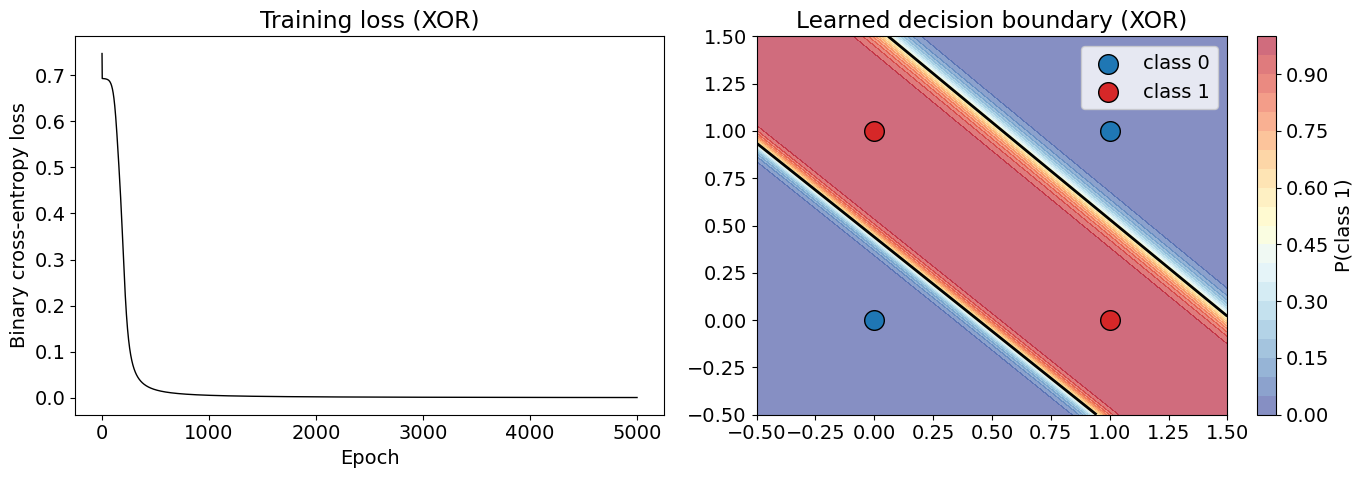

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(losses_xor, 'k-', lw=1)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary cross-entropy loss')
axes[0].set_title('Training loss (XOR)')

xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z_xor, _ = forward(grid, W1_xor, b1_xor, W2_xor, b2_xor)
Z_xor = Z_xor.reshape(xx.shape)

axes[1].contourf(xx, yy, Z_xor, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
axes[1].contour(xx, yy, Z_xor, levels=[0.5], colors='k', linewidths=2)
axes[1].scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], c='tab:blue', s=200,
                edgecolors='k', zorder=5, label='class 0')
axes[1].scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], c='tab:red', s=200,
                edgecolors='k', zorder=5, label='class 1')
axes[1].set_title('Learned decision boundary (XOR)')
axes[1].legend()
plt.colorbar(axes[1].collections[0], ax=axes[1], label='P(class 1)')

plt.tight_layout()
plt.show()

The network learned a **curved** decision boundary that correctly classifies all four XOR points. A single neuron cannot do this — it is mathematically impossible with a linear boundary.

This is the fundamental power of neural networks: by stacking layers, they can represent non-linear decision boundaries.

---
## Breakout Exercise (~10 min)

**Open the Day 2 breakout notebook and work with your partner.**

You have the full training loop from the lecture. Your job: run it on XOR, then break it three ways. Each failure teaches you something about how neural networks work.

We'll discuss as a class before applying the network to the Ising model.

---
## Part 5: The Ising Model — Can the Network Discover the Order Parameter?

Now the real test. We apply our from-scratch network to the Ising phase classification problem. This is a much higher-dimensional problem (100 features instead of 2) but the same code works.

In [13]:
print('Training from-scratch network on Ising data...')
# W1_is, b1_is, W2_is, b2_is, losses_is = train_network(
#     X_tr_is, y_tr_is.astype(float), H=20, lr=0.01, n_epochs=30000
# )

W1_is, b1_is, W2_is, b2_is, losses_is = train_network(
    X_tr_is, y_tr_is.astype(float), H=40, lr=0.1, n_epochs=25000, ndiv=5000
)

# W1_is, b1_is, W2_is, b2_is, losses_is = train_network(
#     X_tr_is, y_tr_is.astype(float), H=50, lr=0.06, n_epochs=100000, ndiv=10000
# )

y_hat_is, _ = forward(X_te_is, W1_is, b1_is, W2_is, b2_is)
y_pred_is = (y_hat_is > 0.5).astype(int)
acc_nn = accuracy_score(y_te_is, y_pred_is)

print(f'\nLogistic regression accuracy: {acc_lr:.2%}')
print(f'Neural network accuracy:      {acc_nn:.2%}')

Training from-scratch network on Ising data...
  epoch     0  loss = 1.1226  acc = 58.07%
  epoch  5000  loss = 0.0218  acc = 99.93%
  epoch 10000  loss = 0.0077  acc = 100.00%
  epoch 15000  loss = 0.0043  acc = 100.00%
  epoch 20000  loss = 0.0029  acc = 100.00%

Logistic regression accuracy: 67.17%
Neural network accuracy:      93.50%


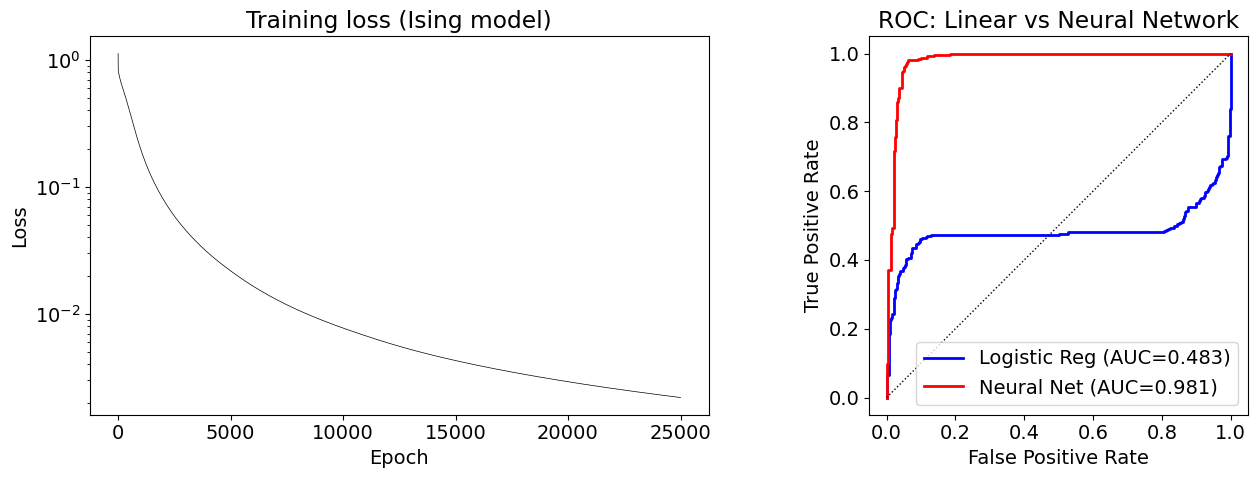

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(losses_is, 'k-', lw=0.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_yscale('log')
axes[0].set_title('Training loss (Ising model)')

y_prob_lr_is = clf_lr_is.predict_proba(X_te_is)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_te_is, y_prob_lr_is)
fpr_nn, tpr_nn, _ = roc_curve(y_te_is, y_hat_is)

axes[1].plot(fpr_lr, tpr_lr, 'b-', lw=2, label=f'Logistic Reg (AUC={auc(fpr_lr, tpr_lr):.3f})')
axes[1].plot(fpr_nn, tpr_nn, 'r-', lw=2, label=f'Neural Net (AUC={auc(fpr_nn, tpr_nn):.3f})')
axes[1].plot([0, 1], [0, 1], 'k:', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC: Linear vs Neural Network')
axes[1].legend()
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

### What did the network learn?

We cannot easily visualize 100-dimensional weights, but we *can* ask: does the network's output correlate with the true order parameter $|M|$?

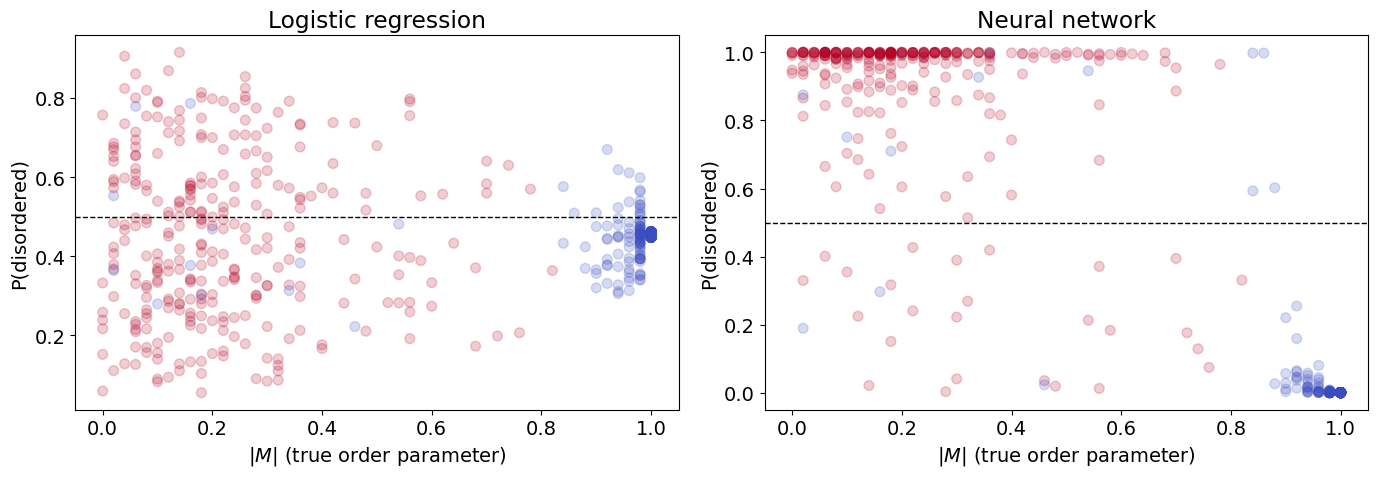

In [15]:
M_abs_test = np.abs(X_te_is.mean(axis=1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(M_abs_test, y_prob_lr_is, c=y_te_is, cmap='coolwarm', alpha=.2, s=50)
axes[0].set_xlabel('$|M|$ (true order parameter)')
axes[0].set_ylabel('P(disordered)')
axes[0].set_title('Logistic regression')
axes[0].axhline(0.5, color='k', ls='--', lw=1)

axes[1].scatter(M_abs_test, y_hat_is, c=y_te_is, cmap='coolwarm', alpha=.2, s=50)
axes[1].set_xlabel('$|M|$ (true order parameter)')
axes[1].set_ylabel('P(disordered)')
axes[1].set_title('Neural network')
axes[1].axhline(0.5, color='k', ls='--', lw=1)

plt.tight_layout()
plt.show()

The neural network's output is a much cleaner function of $|M|$ than logistic regression's. The network has effectively learned to compute something like the absolute magnetization — the true order parameter — from the raw spin data, without being told that $|M|$ is the relevant quantity.

This is a central theme in the application of neural networks to physics: **the network can discover physically meaningful features from raw data.**

---
## Part 6: Understanding the Hyperparameters

Our network has several choices that affect performance. These are **hyperparameters** — not learned during training but set by us. Same concept as $\lambda$ in Module 1 or $k$ in KNN.

### 6.1 Number of hidden neurons (width)

More neurons = more capacity. But too many can overfit.

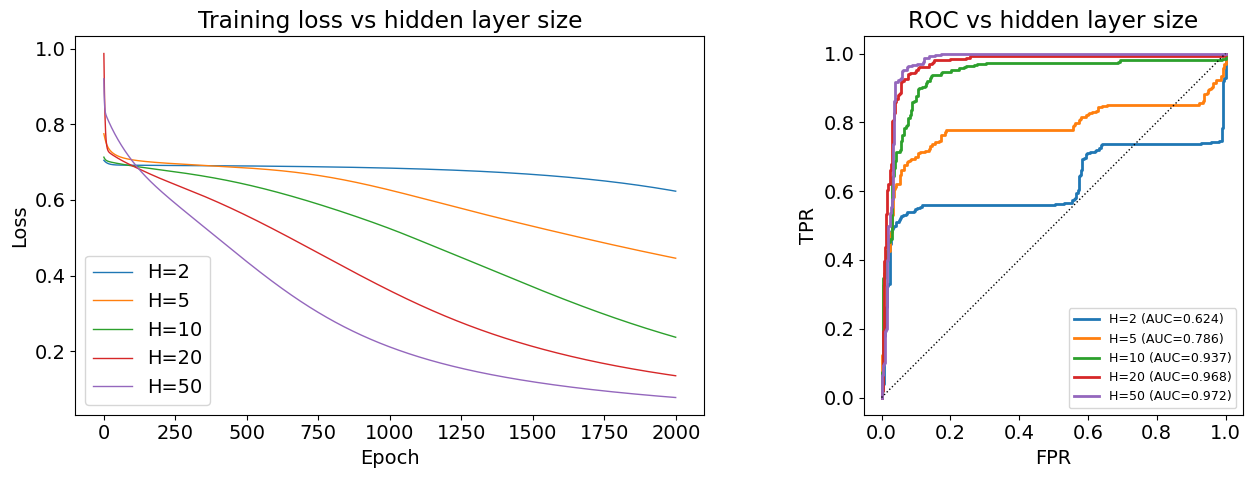

In [16]:
hidden_sizes = [2, 5, 10, 20, 50]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for H in hidden_sizes:
    W1_h, b1_h, W2_h, b2_h, losses_h = train_network(
        X_tr_is, y_tr_is.astype(float), H=H, lr=0.1, n_epochs=2000, verbose=False
    )
    y_hat_h, _ = forward(X_te_is, W1_h, b1_h, W2_h, b2_h)
    axes[0].plot(losses_h, lw=1, label=f'H={H}')
    fpr_h, tpr_h, _ = roc_curve(y_te_is, y_hat_h)
    axes[1].plot(fpr_h, tpr_h, lw=2, label=f'H={H} (AUC={auc(fpr_h, tpr_h):.3f})')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training loss vs hidden layer size'); axes[0].legend()
axes[1].plot([0, 1], [0, 1], 'k:', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC vs hidden layer size'); axes[1].legend(fontsize=9)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

### 6.2 Learning rate

The learning rate $\eta$ controls the step size in gradient descent.
- Too small: slow convergence, may get stuck
- Too large: overshoots, loss oscillates or diverges

Same tradeoff as Module 3's minimization step size.

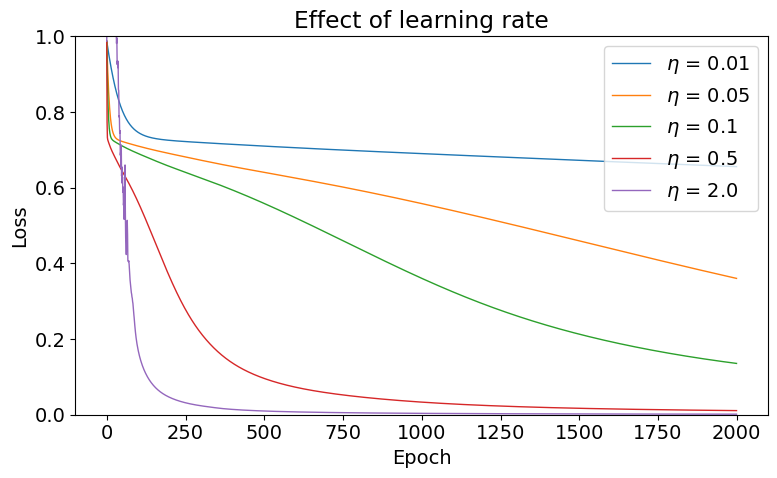

In [17]:
learning_rates = [0.01, 0.05, 0.1, 0.5, 2.0]

fig, ax = plt.subplots(figsize=(8, 5))
for lr in learning_rates:
    _, _, _, _, losses_lr = train_network(
        X_tr_is, y_tr_is.astype(float), H=20, lr=lr, n_epochs=2000, verbose=False
    )
    ax.plot(losses_lr, lw=1, label=f'$\\eta$ = {lr}')

ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Effect of learning rate'); ax.legend()
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

In [18]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def forward_sigmoid(X, W1, b1, W2, b2):
    """Hidden: sigmoid, Output: sigmoid"""
    z1 = X @ W1.T + b1
    h = sigmoid(z1)              # <-- sigmoid activation
    z2 = h @ W2 + b2
    y_hat = sigmoid(z2)
    return y_hat, h

def backward_sigmoid(X, y, y_hat, h, W2):
    """Gradients with sigmoid derivative: h * (1 - h)"""
    N = len(y)
    delta2 = (y_hat - y)
    dW2 = (h.T @ delta2) / N
    db2 = np.mean(delta2)
    delta1 = np.outer(delta2, W2) * h * (1 - h)   # <-- sigmoid derivative
    dW1 = (delta1.T @ X) / N
    db1 = np.mean(delta1, axis=0)
    return dW1, db1, dW2, db2

### 6.3 Activation function

Let's now explore how our choice of activation function effects the learning

forward and backward pass needs to explicitly be written for each activation function case


In [19]:

def forward_tanh(X, W1, b1, W2, b2):
    """Hidden: tanh, Output: sigmoid"""
    z1 = X @ W1.T + b1
    h = np.tanh(z1)              # <-- tanh activation
    z2 = h @ W2 + b2
    y_hat = sigmoid(z2)          # output is still sigmoid (probability)
    return y_hat, h

def backward_tanh(X, y, y_hat, h, W2):
    """Gradients with tanh derivative: 1 - h^2"""
    N = len(y)
    delta2 = (y_hat - y)
    dW2 = (h.T @ delta2) / N
    db2 = np.mean(delta2)
    delta1 = np.outer(delta2, W2) * (1 - h**2)    # <-- tanh derivative
    dW1 = (delta1.T @ X) / N
    db1 = np.mean(delta1, axis=0)
    return dW1, db1, dW2, db2

In [20]:
def relu(z):
    return np.maximum(0, z)

def forward_relu(X, W1, b1, W2, b2):
    """Hidden: ReLU, Output: sigmoid"""
    z1 = X @ W1.T + b1
    h = relu(z1)                 # <-- ReLU activation
    z2 = h @ W2 + b2
    y_hat = sigmoid(z2)          # output is still sigmoid
    return y_hat, h, z1          # also return z1 (needed for ReLU derivative)

def backward_relu(X, y, y_hat, h, z1, W2):
    """Gradients with ReLU derivative: 1 if z > 0, else 0"""
    N = len(y)
    delta2 = (y_hat - y)
    dW2 = (h.T @ delta2) / N
    db2 = np.mean(delta2)
    relu_deriv = (z1 > 0).astype(float)           # <-- ReLU derivative
    delta1 = np.outer(delta2, W2) * relu_deriv
    dW1 = (delta1.T @ X) / N
    db1 = np.mean(delta1, axis=0)
    return dW1, db1, dW2, db2



In [21]:
def train_with_activation(X, y, fwd_fn, bwd_fn, H=20, lr=0.1, n_epochs=3000, seed=0):
    """
    Train a 2-layer network with any activation.
    fwd_fn and bwd_fn must match (same activation in both).
    """
    rng = np.random.default_rng(seed)
    N, D = X.shape
    W1 = rng.standard_normal((H, D)) * 0.5
    b1 = np.zeros(H)
    W2 = rng.standard_normal(H) * 0.5
    b2 = 0.0
    losses = []
    
    is_relu = (fwd_fn == forward_relu)
    
    for epoch in range(n_epochs):
        if is_relu:
            y_hat, h, z1 = fwd_fn(X, W1, b1, W2, b2)
        else:
            y_hat, h = fwd_fn(X, W1, b1, W2, b2)
        
        losses.append(binary_cross_entropy(y, y_hat))
        
        if is_relu:
            dW1, db1_g, dW2, db2_g = bwd_fn(X, y, y_hat, h, z1, W2)
        else:
            dW1, db1_g, dW2, db2_g = bwd_fn(X, y, y_hat, h, W2)
        
        W1 -= lr * dW1
        b1 -= lr * db1_g
        W2 -= lr * dW2
        b2 -= lr * db2_g
    
    return W1, b1, W2, b2, losses



Training with Sigmoid hidden activation...
  Test accuracy: 92.50%

Training with Tanh hidden activation...
  Test accuracy: 86.17%

Training with ReLU hidden activation...
  Test accuracy: 96.00%


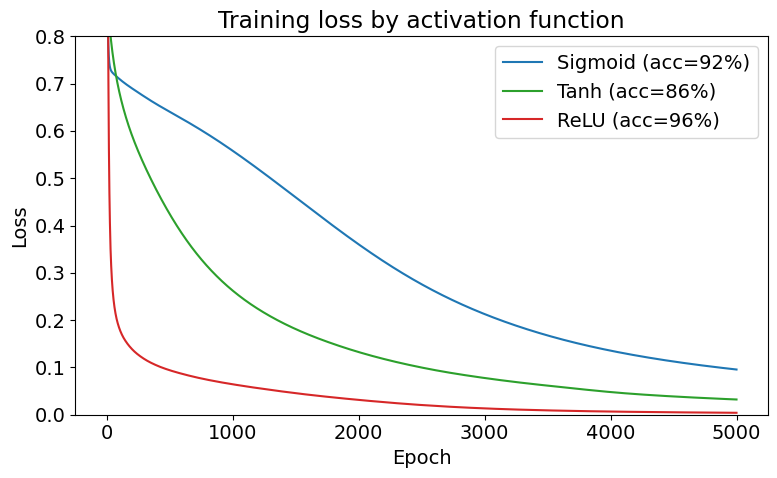

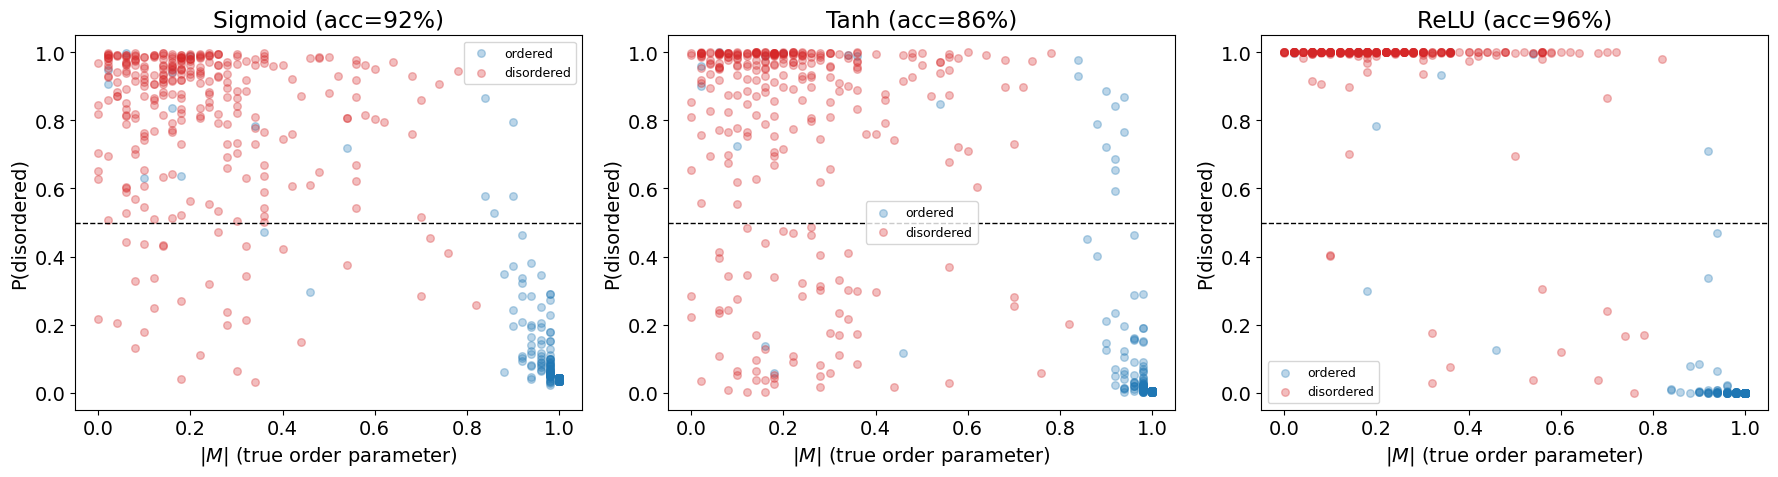

In [22]:
activations = {
    'Sigmoid': (forward_sigmoid, backward_sigmoid),
    'Tanh': (forward_tanh, backward_tanh),
    'ReLU': (forward_relu, backward_relu),
}

colors = {'Sigmoid': 'tab:blue', 'Tanh': 'tab:green', 'ReLU': 'tab:red'}
results = {}

for name, (fwd, bwd) in activations.items():
    print(f'\nTraining with {name} hidden activation...')
    W1, b1, W2, b2, losses = train_with_activation(
        X_tr_is, y_tr_is.astype(float), fwd, bwd, H=20, lr=0.05, n_epochs=5000
    )
    
    # Evaluate on test set
    if fwd == forward_relu:
        y_hat_te, _, _ = fwd(X_te_is, W1, b1, W2, b2)
    else:
        y_hat_te, _ = fwd(X_te_is, W1, b1, W2, b2)
    
    acc = np.mean((y_hat_te > 0.5).astype(int) == y_te_is)
    print(f'  Test accuracy: {acc:.2%}')
    
    results[name] = {'losses': losses, 'y_hat': y_hat_te, 'acc': acc}

# --- Plot 1: Loss curves ---
fig, ax = plt.subplots(figsize=(8, 5))
for name, r in results.items():
    ax.plot(r['losses'], lw=1.5, color=colors[name], label=f"{name} (acc={r['acc']:.0%})")
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training loss by activation function')
ax.legend(); ax.set_ylim(0, 0.8)
plt.tight_layout(); plt.show()

# --- Plot 2: Order parameter comparison (3 panels) ---
M_abs_test = np.abs(X_te_is.mean(axis=1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, r) in zip(axes, results.items()):
    for c, label, color in [(0, 'ordered', 'tab:blue'), (1, 'disordered', 'tab:red')]:
        sel = y_te_is == c
        ax.scatter(M_abs_test[sel], r['y_hat'][sel], c=color, alpha=0.3, s=30, label=label)
    ax.set_xlabel('$|M|$ (true order parameter)')
    ax.set_ylabel('P(disordered)')
    ax.set_title(f"{name} (acc={r['acc']:.0%})")
    ax.axhline(0.5, color='k', ls='--', lw=1)
    ax.legend(fontsize=9)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()





#### 6.3.1 incompatible FWD and BWD passes
What happens if you use ReLU forward but sigmoid backward? i.e. we change the activation function but forget to update the backwards pass

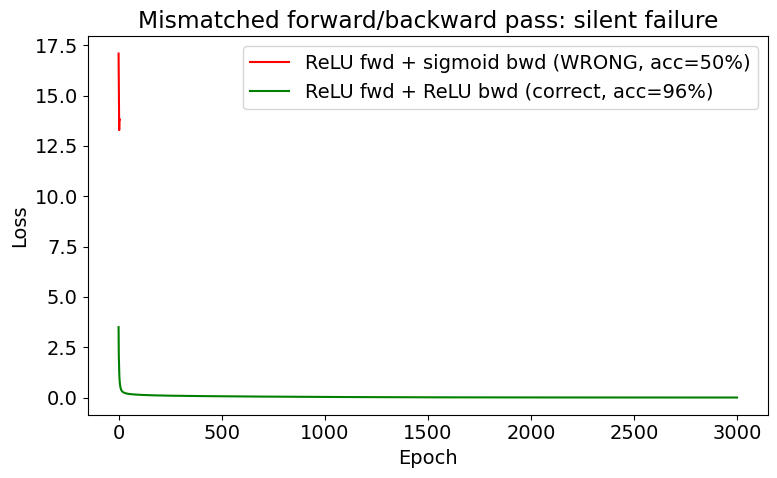


Mismatched (wrong gradients): 50.00%
Correctly matched:           96.00%

The mismatched version may partially train (wrong gradients are not
always zero), but performance is degraded. This is a silent bug —
no error message, just worse results. This is why PyTorch exists.


In [23]:


# Deliberately mismatched: ReLU forward + sigmoid backward
def forward_relu_simple(X, W1, b1, W2, b2):
    """ReLU forward (returns same format as sigmoid forward)."""
    z1 = X @ W1.T + b1
    h = relu(z1)
    z2 = h @ W2 + b2
    y_hat = relu(z2)
    return y_hat, h

# Train with ReLU forward but SIGMOID backward (wrong!)
W1_bad, b1_bad, W2_bad, b2_bad, losses_bad = train_with_activation(
    X_tr_is, y_tr_is.astype(float), forward_relu_simple, backward_sigmoid,
    H=20, lr=0.1, n_epochs=3000
)

y_hat_bad, _ = forward_relu_simple(X_te_is, W1_bad, b1_bad, W2_bad, b2_bad)
acc_bad = np.mean((y_hat_bad > 0.5).astype(int) == y_te_is)

# Compare to correct ReLU
W1_ok, b1_ok, W2_ok, b2_ok, losses_ok = train_with_activation(
    X_tr_is, y_tr_is.astype(float), forward_relu, backward_relu,
    H=20, lr=0.1, n_epochs=3000
)
if True:
    y_hat_ok, _, _ = forward_relu(X_te_is, W1_ok, b1_ok, W2_ok, b2_ok)
acc_ok = np.mean((y_hat_ok > 0.5).astype(int) == y_te_is)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(losses_bad, 'r-', lw=1.5, label=f'ReLU fwd + sigmoid bwd (WRONG, acc={acc_bad:.0%})')
ax.plot(losses_ok, 'g-', lw=1.5, label=f'ReLU fwd + ReLU bwd (correct, acc={acc_ok:.0%})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Mismatched forward/backward pass: silent failure')
ax.legend()
#ax.set_ylim(0, 0.8)
plt.tight_layout()
plt.show()

print(f'\nMismatched (wrong gradients): {acc_bad:.2%}')
print(f'Correctly matched:           {acc_ok:.2%}')
print('\nThe mismatched version may partially train (wrong gradients are not')
print('always zero), but performance is degraded. This is a silent bug —')
print('no error message, just worse results. This is why PyTorch exists.')

---
## Summary

| Concept | What we learned |
|---|---|
| **Loss function** | Binary cross-entropy = negative log-likelihood (same as Modules 1 and 3) |
| **Backpropagation** | Chain rule applied layer by layer to compute gradients |
| **Training** | Gradient descent on all parameters simultaneously |
| **XOR** | Simplest proof that NNs can learn what linear classifiers cannot |
| **Ising model** | The network discovered the order parameter $|M|$ from raw spins |
| **Hyperparameters** | Hidden size, learning rate — same bias-variance tradeoff as always |

### The big picture

A neural network is not a mysterious black box. It is:
- Logistic regression (Module 4) applied to...
- Learned non-linear features, trained by...
- Gradient descent (Module 3) on...
- A likelihood-based loss function (Module 1)

Everything connects back to what you already know.

### Next time

We will move from our from-scratch implementation to using **PyTorch**, which handles backpropagation automatically. We will also explore network depth, overfitting, and activation function choices.

---
## Remaining class time: work on HW 5

Continue working on Problems 1 and 2 with your partner. Problem 1 extends what we did today — the full forward and backward pass by hand. Problem 2 asks you to modify the code (tanh activation, add a second hidden layer).

